# Notebook 01 — Retrieval-Augmented Generation (RAG) Basics

This notebook on **RAG** as a practical, end-to-end pipeline.

You will implement (cell-by-cell):

1. Environment setup (**GPU if available**, automatic **CPU fallback**).
2. A small **knowledge base** (documents + metadata).
3. **Chunking** (token-aware, with overlap).
4. **Embeddings** (Sentence Transformers).
5. A **vector index** (FAISS) and a **retriever**.
6. A simple **RAG generator** (small open-source seq2seq model).
7. **Evaluation**:
   - Retrieval metrics: *Recall@k*, *MRR*, *nDCG*.
   - Generation metrics: *Exact Match*, *Token F1* + a basic *citation/grounding* check.

Notes:
- This notebook is **self-contained**: it uses a toy corpus so it runs even without external datasets.
- You can later swap the toy corpus for your own PDFs or a larger dataset.


## 1) Install dependencies

We install a minimal stack:
- `transformers`, `accelerate`: for the generative model
- `sentence-transformers`: for embeddings
- `faiss-cpu`: vector similarity search
- `numpy`, `pandas`, `matplotlib`: analysis & reporting

If you run this locally, you might already have some of these packages.


In [ ]:
# If you are in Colab, you may want to restart runtime after installations.

import sys, subprocess

def pip_install(pkgs):
    print("Installing:", pkgs)
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + pkgs)

pip_install([
    "numpy>=1.24",
    "pandas>=2.0",
    "matplotlib>=3.7",
    "scikit-learn>=1.3",
    "transformers>=4.41",
    "accelerate>=0.30",
    "sentence-transformers>=2.6",
    "faiss-cpu>=1.8.0",
])

print("Done.")


Installing: ['numpy>=1.24', 'pandas>=2.0', 'matplotlib>=3.7', 'scikit-learn>=1.3', 'transformers>=4.41', 'accelerate>=0.30', 'sentence-transformers>=2.6', 'faiss-cpu>=1.8.0']
Done.


## 2) Import libraries + set deterministic behavior

We import Python libraries and set:
- a random seed (for reproducibility),
- basic utility functions we will reuse.


In [ ]:
import os
import re
import math
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print("Python:", __import__("sys").version.split()[0])
print("Torch:", torch.__version__)


Python: 3.12.12
Torch: 2.9.0+cu126


## 3) Detect GPU (and define a safe device strategy)

We prefer GPU when available, but we must be robust:

- If `torch.cuda.is_available()` → use `cuda`
- Else → use `cpu`

For the generator model, we also implement an OOM fallback:
- Try to load/run on GPU
- If it fails with out-of-memory, move to CPU and continue


In [ ]:
def get_device():
    if torch.cuda.is_available():
        return torch.device("cuda")
    return torch.device("cpu")

DEVICE = get_device()
print("Selected device:", DEVICE)

if DEVICE.type == "cuda":
    print("GPU name:", torch.cuda.get_device_name(0))


Selected device: cuda
GPU name: NVIDIA A100-SXM4-80GB


## 4) Create a small "knowledge base" (documents + metadata)

A RAG system needs a searchable collection. In real systems this would come from:
- PDFs, web pages, wikis, internal docs, tickets, etc.

Here we build a toy corpus that still demonstrates the full pipeline:
- Each document has an `id`, `title`, and `text`.
- Later, these IDs are used as citations.

We intentionally include overlapping topics so retrieval quality matters.


In [ ]:
DOCUMENTS = [
    {
        "id": "D01",
        "title": "What is RAG?",
        "text": (
            "Retrieval-Augmented Generation (RAG) combines information retrieval with text generation. "
            "A retriever selects relevant documents or passages from a knowledge base. "
            "A generator then conditions on those passages to produce an answer. "
            "RAG can reduce hallucinations by grounding responses in retrieved evidence, but it depends "
            "on retrieval quality, chunking, and how the prompt is constructed."
        ),
    },
    {
        "id": "D02",
        "title": "Chunking and overlap",
        "text": (
            "Chunking splits long documents into smaller passages. "
            "Overlap means consecutive chunks share some tokens to reduce boundary effects. "
            "If chunks are too small, important context may be fragmented; if too large, retrieval gets noisy "
            "and the generator may exceed context limits. Chunk size and overlap are key hyperparameters."
        ),
    },
    {
        "id": "D03",
        "title": "Embeddings for retrieval",
        "text": (
            "Dense retrieval uses embeddings to map texts into vectors. Similarity search (e.g., cosine similarity) "
            "retrieves the nearest vectors for a query embedding. Sentence Transformers are commonly used for "
            "creating embeddings. Embedding normalization allows inner product search to approximate cosine similarity."
        ),
    },
    {
        "id": "D04",
        "title": "FAISS vector indexes",
        "text": (
            "FAISS is a library for efficient similarity search over vectors. "
            "Simple indexes like IndexFlatIP perform exact search using inner product. "
            "More advanced indexes (IVF, HNSW, PQ) trade accuracy for speed and memory savings."
        ),
    },
    {
        "id": "D05",
        "title": "Hallucinations and grounding",
        "text": (
            "A hallucination is when a model outputs content that is not supported by evidence. "
            "Grounding is the practice of tying claims to retrieved sources. "
            "Even with RAG, hallucinations can happen if the retriever returns irrelevant passages, "
            "or if the model ignores them. Evaluation should measure both retrieval quality and evidence usage."
        ),
    },
    {
        "id": "D06",
        "title": "Evaluating retrieval",
        "text": (
            "Common retrieval metrics include Recall@k, Mean Reciprocal Rank (MRR), and nDCG. "
            "Recall@k checks if any relevant document appears in the top-k results. "
            "MRR rewards placing a relevant document as early as possible. "
            "nDCG also accounts for ranking position and graded relevance."
        ),
    },
    {
        "id": "D07",
        "title": "Quantization and compression",
        "text": (
            "Quantization reduces memory by storing weights with lower precision (e.g., INT8, INT4). "
            "Post-training quantization (PTQ) applies quantization after training, while QAT includes it during training. "
            "Pruning removes weights or neurons, and distillation trains a smaller student model to mimic a teacher."
        ),
    },
    {
        "id": "D08",
        "title": "Distillation",
        "text": (
            "Knowledge distillation trains a smaller student model using a larger teacher model. "
            "The student can learn from soft targets (probabilities) produced by the teacher, often using a temperature "
            "to smooth distributions. Distillation aims to keep performance while improving speed and memory."
        ),
    },
    {
        "id": "D09",
        "title": "Prompt injection (brief)",
        "text": (
            "Prompt injection attacks attempt to override system instructions by inserting malicious text into user input "
            "or retrieved documents. In RAG systems, retrieved content can contain hidden instructions. "
            "Mitigations include content filtering, role separation, and strict tool allowlists."
        ),
    },
    {
        "id": "D10",
        "title": "Hybrid retrieval (brief)",
        "text": (
            "Hybrid retrieval combines sparse methods (like BM25) with dense embeddings. "
            "Sparse retrieval is strong for exact keyword matches; dense retrieval is strong for semantic similarity. "
            "Combining them can improve robustness across query types."
        ),
    },
]

docs_df = pd.DataFrame([{"id": d["id"], "title": d["title"], "length_chars": len(d["text"])} for d in DOCUMENTS])
docs_df


,id,title,length_chars
0,D01,What is RAG?,389
1,D02,Chunking and overlap,322
2,D03,Embeddings for retrieval,306
3,D04,FAISS vector indexes,221
4,D05,Hallucinations and grounding,332
5,D06,Evaluating retrieval,275
6,D07,Quantization and compression,300
7,D08,Distillation,287
8,D09,Prompt injection (brief),283
9,D10,Hybrid retrieval (brief),238


## 5) Token-aware chunking function

Why token-aware chunking?
- Generative models and embedding models have token limits.
- Chunking by characters can be misleading (tokenization is not uniform).

We implement a chunker that:
- tokenizes the text,
- splits into windows of `max_tokens`,
- applies an `overlap_tokens` stride,
- returns chunks with metadata that preserves the original document ID.

We will use the tokenizer from the embedding model, because chunk size is primarily for retrieval.


In [ ]:
from transformers import AutoTokenizer

EMBED_MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"
embed_tokenizer = AutoTokenizer.from_pretrained(EMBED_MODEL_NAME)

def chunk_text_tokenwise(text: str, max_tokens: int = 128, overlap_tokens: int = 32):
    assert max_tokens > 0
    assert 0 <= overlap_tokens < max_tokens

    token_ids = embed_tokenizer.encode(text, add_special_tokens=False)
    chunks = []

    start = 0
    while start < len(token_ids):
        end = min(start + max_tokens, len(token_ids))
        chunk_ids = token_ids[start:end]
        chunk_text = embed_tokenizer.decode(chunk_ids)

        chunks.append({
            "chunk_text": chunk_text,
            "token_start": start,
            "token_end": end,
        })

        if end == len(token_ids):
            break
        start = end - overlap_tokens

    return chunks

# Sanity check
sample_chunks = chunk_text_tokenwise(DOCUMENTS[0]["text"], max_tokens=60, overlap_tokens=15)
len(sample_chunks), sample_chunks[0]["chunk_text"][:200]


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

(2,
 'retrieval - augmented generation ( rag ) combines information retrieval with text generation. a retriever selects relevant documents or passages from a knowledge base. a generator then conditions on t')

## 6) Build the chunk collection

We apply chunking to all documents and build a chunk table:

Each chunk gets:
- `chunk_id` (unique)
- `doc_id` (citation ID)
- `title`
- `text` (chunk content)

This is what we will embed and index.


In [ ]:
def build_chunks(docs, max_tokens=128, overlap_tokens=32):
    rows = []
    chunk_counter = 0
    for d in docs:
        chunks = chunk_text_tokenwise(d["text"], max_tokens=max_tokens, overlap_tokens=overlap_tokens)
        for c in chunks:
            chunk_counter += 1
            rows.append({
                "chunk_id": f"C{chunk_counter:04d}",
                "doc_id": d["id"],
                "title": d["title"],
                "text": c["chunk_text"],
                "token_start": c["token_start"],
                "token_end": c["token_end"],
            })
    return pd.DataFrame(rows)

CHUNK_MAX_TOKENS = 128
CHUNK_OVERLAP_TOKENS = 32

chunks_df = build_chunks(DOCUMENTS, CHUNK_MAX_TOKENS, CHUNK_OVERLAP_TOKENS)
print("Num docs:", len(DOCUMENTS))
print("Num chunks:", len(chunks_df))
chunks_df.head()


Num docs: 10
Num chunks: 10


,chunk_id,doc_id,title,text,token_start,token_end
0,C0001,D01,What is RAG?,retrieval - augmented generation ( rag ) combi...,0,70
1,C0002,D02,Chunking and overlap,chunking splits long documents into smaller pa...,0,60
2,C0003,D03,Embeddings for retrieval,dense retrieval uses embeddings to map texts i...,0,66
3,C0004,D04,FAISS vector indexes,faiss is a library for efficient similarity se...,0,50
4,C0005,D05,Hallucinations and grounding,a hallucination is when a model outputs conten...,0,63


## 7) Compute embeddings for chunks (GPU if available)

We embed every chunk using a Sentence Transformer.

Key points:
- We batch embeddings to avoid memory spikes.
- We normalize embeddings so that inner product approximates cosine similarity.
- Embedding computation will use GPU automatically if available.

This will produce:
- `chunk_embeddings`: NumPy array of shape (num_chunks, dim)


In [ ]:
from sentence_transformers import SentenceTransformer

embedder = SentenceTransformer(EMBED_MODEL_NAME, device=str(DEVICE))

def embed_texts(texts, batch_size=32, normalize=True):
    vecs = embedder.encode(
        texts,
        batch_size=batch_size,
        show_progress_bar=True,
        convert_to_numpy=True,
        normalize_embeddings=normalize,
    )
    return vecs

chunk_embeddings = embed_texts(chunks_df["text"].tolist(), batch_size=32, normalize=True)
chunk_embeddings.shape


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/90.9M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

(10, 384)

## 8) Build the FAISS index (vector store)

We create a FAISS index for inner product search:
- With normalized vectors, inner product equals cosine similarity.

We store:
- the FAISS index,
- and rely on `chunks_df.iloc[i]` as the mapping from index row → chunk metadata.


In [ ]:
import faiss

dim = chunk_embeddings.shape[1]
index = faiss.IndexFlatIP(dim)
index.add(chunk_embeddings.astype(np.float32))

print("FAISS index size:", index.ntotal)


FAISS index size: 10


## 9) Retrieval function

Given a query:
1. Embed the query with the same embedder
2. Search FAISS for top-k chunks
3. Return a DataFrame with scores and metadata

We also provide a helper to display retrieved chunks.


In [ ]:
def retrieve(query: str, k: int = 5) -> pd.DataFrame:
    q_emb = embed_texts([query], batch_size=1, normalize=True).astype(np.float32)
    scores, idxs = index.search(q_emb, k)
    scores = scores[0].tolist()
    idxs = idxs[0].tolist()

    rows = []
    for rank, (score, i) in enumerate(zip(scores, idxs), start=1):
        if i == -1:
            continue
        row = chunks_df.iloc[i].to_dict()
        row.update({"rank": rank, "score": float(score)})
        rows.append(row)
    return pd.DataFrame(rows)

def pretty_print_retrieval(df: pd.DataFrame, max_chars=350):
    for _, r in df.iterrows():
        snippet = r["text"].replace("\n", " ").strip()
        if len(snippet) > max_chars:
            snippet = snippet[:max_chars] + "..."
        print(f"[rank={int(r['rank'])} score={r['score']:.3f}] {r['doc_id']} — {r['title']} (chunk {r['chunk_id']})")
        print(" ", snippet)
        print()

demo_q = "What is RAG and why can it reduce hallucinations?"
top = retrieve(demo_q, k=5)
top[["rank", "score", "doc_id", "title", "chunk_id"]]


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

,rank,score,doc_id,title,chunk_id
0,1,0.499685,D01,What is RAG?,C0001
1,2,0.473570,D05,Hallucinations and grounding,C0005
2,3,0.293365,D09,Prompt injection (brief),C0009
3,4,0.153422,D07,Quantization and compression,C0007
4,5,0.117624,D02,Chunking and overlap,C0002


## 10) Inspect retrieval results (qualitative)

Before generation, visually inspect retrieval quality:
- Do we get the right documents?
- Are chunks coherent?
- Are there duplicates from the same doc?

This helps debug chunking and embedding model choice.


In [ ]:
pretty_print_retrieval(top)


[rank=1 score=0.500] D01 — What is RAG? (chunk C0001)
  retrieval - augmented generation ( rag ) combines information retrieval with text generation. a retriever selects relevant documents or passages from a knowledge base. a generator then conditions on those passages to produce an answer. rag can reduce hallucinations by grounding responses in retrieved evidence, but it depends on retrieval quality, c...

[rank=2 score=0.474] D05 — Hallucinations and grounding (chunk C0005)
  a hallucination is when a model outputs content that is not supported by evidence. grounding is the practice of tying claims to retrieved sources. even with rag, hallucinations can happen if the retriever returns irrelevant passages, or if the model ignores them. evaluation should measure both retrieval quality and evidence usage.

[rank=3 score=0.293] D09 — Prompt injection (brief) (chunk C0009)
  prompt injection attacks attempt to override system instructions by inserting malicious text into user input or ret

## 11) Build a simple RAG prompt

We create an augmented prompt:
- Instructions to encourage grounding
- Retrieved contexts with explicit citations (Doc IDs)
- The user question

We ask the model to:
- Answer concisely
- Cite sources as `[Dxx]`
- If evidence is insufficient, say so


In [ ]:
def build_rag_prompt(question: str, retrieved_chunks: pd.DataFrame, max_context_chunks: int = 4) -> str:
    ctx = retrieved_chunks.sort_values("rank").head(max_context_chunks)

    context_blocks = []
    for _, r in ctx.iterrows():
        context_blocks.append(f"[{r['doc_id']}] {r['text'].strip()}")

    context_text = "\n\n".join(context_blocks)

    header_lines = [
        "You are a careful assistant. Use ONLY the provided sources to answer.",
        'If the sources do not contain enough information, say: "I don\'t have enough evidence in the provided sources."',
        "",
        "Rules:",
        "- Provide a short answer (3-6 sentences).",
        "- Add citations at the end of sentences using the form [Dxx].",
        "- Do not invent citations.",
        "",
        "SOURCES:",
    ]

    prompt = "\n".join(header_lines) + "\n" + context_text + "\n\nQUESTION:\n" + question + "\n\nANSWER:"
    return prompt

prompt = build_rag_prompt(demo_q, top, max_context_chunks=4)
print(prompt[:900], "...\n\n[Prompt length chars:", len(prompt), "]")


You are a careful assistant. Use ONLY the provided sources to answer.
If the sources do not contain enough information, say: "I don't have enough evidence in the provided sources."

Rules:
- Provide a short answer (3-6 sentences).
- Add citations at the end of sentences using the form [Dxx].
- Do not invent citations.

SOURCES:
[D01] retrieval - augmented generation ( rag ) combines information retrieval with text generation. a retriever selects relevant documents or passages from a knowledge base. a generator then conditions on those passages to produce an answer. rag can reduce hallucinations by grounding responses in retrieved evidence, but it depends on retrieval quality, chunking, and how the prompt is constructed.

[D05] a hallucination is when a model outputs content that is not supported by evidence. grounding is the practice of tying claims to retrieved sources. even with rag, h ...

[Prompt length chars: 1745 ]


## 12) Load a small generator model (GPU preferred, CPU fallback)

We use a lightweight seq2seq model so that it can run:
- On GPU (faster)
- On CPU (fallback)

Model: FLAN-T5-base
- Small enough for demonstration
- Instruction-tuned enough to follow "cite sources" prompts reasonably well

If GPU inference fails (OOM), we automatically move the model to CPU.


In [ ]:
from transformers import AutoModelForSeq2SeqLM, AutoTokenizer

GEN_MODEL_NAME = "google/flan-t5-base"
gen_tokenizer = AutoTokenizer.from_pretrained(GEN_MODEL_NAME)

def load_generator(device: torch.device):
    model = AutoModelForSeq2SeqLM.from_pretrained(GEN_MODEL_NAME)
    model.to(device)
    model.eval()
    return model

def safe_generate(model, tokenizer, prompt: str, device: torch.device, max_new_tokens: int = 160):
    try:
        inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=1024).to(device)
        with torch.no_grad():
            outputs = model.generate(
                **inputs,
                max_new_tokens=max_new_tokens,
                do_sample=False,
                num_beams=2,
            )
        return tokenizer.decode(outputs[0], skip_special_tokens=True).strip(), device
    except RuntimeError as e:
        msg = str(e).lower()
        if "out of memory" in msg or "cuda" in msg:
            print("Generation failed on GPU (likely OOM). Falling back to CPU.")
            if torch.cuda.is_available():
                torch.cuda.empty_cache()
            cpu_device = torch.device("cpu")
            model = model.to(cpu_device)
            inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=1024).to(cpu_device)
            with torch.no_grad():
                outputs = model.generate(
                    **inputs,
                    max_new_tokens=max_new_tokens,
                    do_sample=False,
                    num_beams=2,
                )
            return tokenizer.decode(outputs[0], skip_special_tokens=True).strip(), cpu_device
        raise

gen_model = load_generator(DEVICE)
print("Generator loaded on:", DEVICE)


tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

Generator loaded on: cuda


## 13) End-to-end RAG answer

We now combine:
- retrieval → prompt construction → generation

We also extract cited doc IDs from the answer to support evaluation later.


In [ ]:
def extract_citations(answer: str):
    return sorted(set(re.findall(r"\[(D\d{2})\]", answer)))

def rag_answer(question: str, k_retrieve: int = 5, max_context_chunks: int = 4):
    retrieved = retrieve(question, k=k_retrieve)
    prompt = build_rag_prompt(question, retrieved, max_context_chunks=max_context_chunks)
    answer, used_device = safe_generate(gen_model, gen_tokenizer, prompt, device=DEVICE, max_new_tokens=160)
    return {
        "question": question,
        "retrieved": retrieved,
        "prompt": prompt,
        "answer": answer,
        "citations": extract_citations(answer),
        "device_used": str(used_device),
    }

result = rag_answer(demo_q, k_retrieve=5, max_context_chunks=4)
print("Device used:", result["device_used"])
print("Citations found:", result["citations"])
print("\nANSWER:\n", result["answer"])


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Device used: cuda
Citations found: ['D05']

ANSWER:
 retrieval - augmented generation ( rag ) combines information retrieval with text generation. a retriever selects relevant documents or passages from a knowledge base. a generator then conditions on those passages to produce an answer. rag can reduce hallucinations by grounding responses in retrieved evidence, but it depends on retrieval quality, chunking, and how the prompt is constructed. [D05] a hallucination is when a model outputs content that is not supported by evidence. grounding is the practice of tying claims to retrieved sources. even with rag, hallucinations can happen if the retriever returns irrelevant passages, or if the model ignores them. evaluation should measure


## 14) Build an evaluation set (queries with gold sources)

To evaluate retrieval, we need:
- a query
- a set of relevant doc IDs (gold sources)

We also add a reference answer for simple generation scoring (EM/F1).
In real projects, these labels come from human annotation.

Here we create a small curated set so you can:
- compute retrieval metrics
- observe how retrieval affects generation


In [ ]:
EVAL_SET = [
    {
        "question": "Define Retrieval-Augmented Generation (RAG).",
        "gold_docs": {"D01"},
        "reference_answer": "RAG combines retrieval of relevant documents with generation conditioned on those documents."
    },
    {
        "question": "Why can RAG reduce hallucinations, and why can it still fail?",
        "gold_docs": {"D01", "D05"},
        "reference_answer": "RAG can reduce hallucinations by grounding answers in retrieved evidence, but it can fail when retrieval is poor or the model ignores sources."
    },
    {
        "question": "What is chunk overlap and why is it used?",
        "gold_docs": {"D02"},
        "reference_answer": "Chunk overlap shares tokens between consecutive chunks to reduce boundary effects and preserve context."
    },
    {
        "question": "Name three common retrieval evaluation metrics and what they measure.",
        "gold_docs": {"D06"},
        "reference_answer": "Recall@k checks if a relevant item is in the top-k, MRR rewards early relevant results, and nDCG accounts for ranking position and graded relevance."
    },
    {
        "question": "What does FAISS do in a RAG pipeline?",
        "gold_docs": {"D04"},
        "reference_answer": "FAISS performs efficient similarity search over embedding vectors to retrieve the most similar chunks for a query."
    },
    {
        "question": "What is knowledge distillation at a high level?",
        "gold_docs": {"D08"},
        "reference_answer": "Distillation trains a smaller student model to mimic a larger teacher model, often using soft targets."
    },
    {
        "question": "What is quantization and what are PTQ and QAT?",
        "gold_docs": {"D07"},
        "reference_answer": "Quantization stores weights at lower precision; PTQ applies it after training and QAT applies it during training."
    },
    {
        "question": "What is prompt injection in the context of RAG, and name one mitigation idea.",
        "gold_docs": {"D09"},
        "reference_answer": "Prompt injection tries to override instructions via malicious input or retrieved text; mitigations include filtering or role separation."
    },
]

eval_df = pd.DataFrame([{
    "question": x["question"],
    "gold_docs": ", ".join(sorted(x["gold_docs"])),
} for x in EVAL_SET])

eval_df


,question,gold_docs
0,Define Retrieval-Augmented Generation (RAG).,D01
1,"Why can RAG reduce hallucinations, and why can...","D01, D05"
2,What is chunk overlap and why is it used?,D02
3,Name three common retrieval evaluation metrics...,D06
4,What does FAISS do in a RAG pipeline?,D04
5,What is knowledge distillation at a high level?,D08
6,What is quantization and what are PTQ and QAT?,D07
7,What is prompt injection in the context of RAG...,D09


## 15) Retrieval evaluation metrics (Recall@k, MRR, nDCG)

We implement classic IR metrics:

- Recall@k: Did we retrieve any gold doc in top-k?
- MRR: Reciprocal rank of the first relevant result.
- nDCG@k: Ranking-quality metric; here we use binary relevance.

We evaluate at multiple k values to see sensitivity.


In [ ]:
def recall_at_k(retrieved_doc_ids, gold_doc_ids, k):
    topk = retrieved_doc_ids[:k]
    return 1.0 if any(d in gold_doc_ids for d in topk) else 0.0

def mrr(retrieved_doc_ids, gold_doc_ids):
    for i, d in enumerate(retrieved_doc_ids, start=1):
        if d in gold_doc_ids:
            return 1.0 / i
    return 0.0

def ndcg_at_k(retrieved_doc_ids, gold_doc_ids, k):
    def dcg(docs):
        s = 0.0
        for i, d in enumerate(docs, start=1):
            rel = 1.0 if d in gold_doc_ids else 0.0
            s += (2**rel - 1) / math.log2(i + 1)
        return s

    topk = retrieved_doc_ids[:k]
    dcg_k = dcg(topk)

    ideal = list(gold_doc_ids) + [d for d in retrieved_doc_ids if d not in gold_doc_ids]
    idcg_k = dcg(ideal[:k])

    return 0.0 if idcg_k == 0 else dcg_k / idcg_k

def evaluate_retrieval(eval_set, k_values=(1,3,5)):
    rows = []
    for ex in eval_set:
        r = retrieve(ex["question"], k=max(k_values))

        doc_ranking = []
        for d in r.sort_values("rank")["doc_id"].tolist():
            if d not in doc_ranking:
                doc_ranking.append(d)

        gold = set(ex["gold_docs"])

        row = {"question": ex["question"], "gold_docs": gold, "doc_ranking": doc_ranking}
        for k in k_values:
            row[f"Recall@{k}"] = recall_at_k(doc_ranking, gold, k)
            row[f"nDCG@{k}"] = ndcg_at_k(doc_ranking, gold, k)
        row["MRR"] = mrr(doc_ranking, gold)
        rows.append(row)

    return pd.DataFrame(rows)

retrieval_eval = evaluate_retrieval(EVAL_SET, k_values=(1,3,5))
retrieval_eval[["MRR","Recall@1","Recall@3","Recall@5","nDCG@1","nDCG@3","nDCG@5"]].mean()


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

,0
MRR,0.937500
Recall@1,0.875000
Recall@3,1.000000
Recall@5,1.000000
nDCG@1,0.875000
nDCG@3,0.953866
nDCG@5,0.953866


## 16) Inspect retrieval errors

If metrics are not perfect, we need to see why.
This cell prints the doc ranking for each query and highlights whether the gold docs were retrieved.

This is the core debugging workflow for RAG:
- if retrieval fails, generation quality will usually collapse.


In [ ]:
def print_retrieval_diagnostics(retrieval_eval_df, max_rank=5):
    for _, row in retrieval_eval_df.iterrows():
        gold = row["gold_docs"]
        ranking = row["doc_ranking"][:max_rank]
        hits = [d for d in ranking if d in gold]
        print("Q:", row["question"])
        print("Gold docs:", sorted(gold))
        print("Top docs:", ranking)
        print("Hits in top:", hits if hits else "None")
        print("-"*80)

print_retrieval_diagnostics(retrieval_eval, max_rank=5)


Q: Define Retrieval-Augmented Generation (RAG).
Gold docs: ['D01']
Top docs: ['D01', 'D06', 'D03', 'D05', 'D10']
Hits in top: ['D01']
--------------------------------------------------------------------------------
Q: Why can RAG reduce hallucinations, and why can it still fail?
Gold docs: ['D01', 'D05']
Top docs: ['D05', 'D01', 'D09', 'D07', 'D02']
Hits in top: ['D05', 'D01']
--------------------------------------------------------------------------------
Q: What is chunk overlap and why is it used?
Gold docs: ['D02']
Top docs: ['D02', 'D01', 'D03', 'D09', 'D07']
Hits in top: ['D02']
--------------------------------------------------------------------------------
Q: Name three common retrieval evaluation metrics and what they measure.
Gold docs: ['D06']
Top docs: ['D06', 'D01', 'D03', 'D10', 'D04']
Hits in top: ['D06']
--------------------------------------------------------------------------------
Q: What does FAISS do in a RAG pipeline?
Gold docs: ['D04']
Top docs: ['D01', 'D04', 'D

## 17) Generation evaluation: Exact Match + Token F1 + citation check

Generation evaluation is harder than retrieval evaluation.

Here we implement:
- Exact Match (EM): normalized string match to a short reference answer
- Token F1: token overlap between answer and reference (SQuAD-style)

Because this is RAG, we add a basic check:
- Did the model cite at least one gold doc ID?

This is a simplified proxy for grounding.


In [ ]:
def normalize_text(s: str) -> str:
    s = s.lower()
    s = re.sub(r"\s+", " ", s).strip()
    s = re.sub(r"[^a-z0-9\s]", "", s)
    return s

def exact_match(pred: str, ref: str) -> float:
    return 1.0 if normalize_text(pred) == normalize_text(ref) else 0.0

def token_f1(pred: str, ref: str) -> float:
    pred_toks = normalize_text(pred).split()
    ref_toks = normalize_text(ref).split()
    if len(pred_toks) == 0 and len(ref_toks) == 0:
        return 1.0
    if len(pred_toks) == 0 or len(ref_toks) == 0:
        return 0.0

    common = {}
    for t in pred_toks:
        common[t] = common.get(t, 0) + 1

    num_same = 0
    for t in ref_toks:
        if common.get(t, 0) > 0:
            num_same += 1
            common[t] -= 1

    if num_same == 0:
        return 0.0
    precision = num_same / len(pred_toks)
    recall = num_same / len(ref_toks)
    return 2 * precision * recall / (precision + recall)

def evaluate_generation(eval_set, k_retrieve=5, max_context_chunks=4):
    rows = []
    for ex in eval_set:
        out = rag_answer(ex["question"], k_retrieve=k_retrieve, max_context_chunks=max_context_chunks)
        pred = out["answer"]
        ref = ex["reference_answer"]
        gold = set(ex["gold_docs"])
        cited = set(out["citations"])

        rows.append({
            "question": ex["question"],
            "gold_docs": ", ".join(sorted(gold)),
            "citations": ", ".join(sorted(cited)) if cited else "",
            "EM": exact_match(pred, ref),
            "F1": token_f1(pred, ref),
            "CitesGoldDoc": 1.0 if len(gold.intersection(cited)) > 0 else 0.0,
            "answer": pred,
        })
    return pd.DataFrame(rows)

gen_eval = evaluate_generation(EVAL_SET, k_retrieve=5, max_context_chunks=4)
gen_eval[["EM","F1","CitesGoldDoc"]].mean()


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

,0
EM,0.000000
F1,0.237464
CitesGoldDoc,0.125000


## 18) Review answers (qualitative)

Metrics are helpful, but for RAG you should also read outputs:
- Are citations present?
- Are they plausible?
- Are answers grounded or generic?

This cell prints each question + the model answer.


In [ ]:
for i, row in gen_eval.iterrows():
    print(f"#{i+1} Q: {row['question']}")
    print("Gold docs:", row["gold_docs"])
    print("Citations:", row["citations"] if row["citations"] else "(none)")
    print("Answer:", row["answer"])
    print("-"*100)


#1 Q: Define Retrieval-Augmented Generation (RAG).
Gold docs: D01
Citations: (none)
Answer: Provide a short answer (3-6 sentences).
----------------------------------------------------------------------------------------------------
#2 Q: Why can RAG reduce hallucinations, and why can it still fail?
Gold docs: D01, D05
Citations: (none)
Answer: It depends on retrieval quality, chunking, and how the prompt is constructed.
----------------------------------------------------------------------------------------------------
#3 Q: What is chunk overlap and why is it used?
Gold docs: D02
Citations: (none)
Answer: to reduce boundary effects. if chunks are too small, important context may be fragmented ; if too large, retrieval gets noisy and the generator may exceed context limits. chunk size and overlap are key hyperparameters.
----------------------------------------------------------------------------------------------------
#4 Q: Name three common retrieval evaluation metrics and what the

## 19) Summarize results (tables + plot)

We produce:
- retrieval summary table
- generation summary table
- a simple plot for retrieval Recall@k


In [ ]:
retrieval_summary = retrieval_eval[["MRR","Recall@1","Recall@3","Recall@5","nDCG@1","nDCG@3","nDCG@5"]].mean().to_frame("mean")
retrieval_summary


,mean
MRR,0.937500
Recall@1,0.875000
Recall@3,1.000000
Recall@5,1.000000
nDCG@1,0.875000
nDCG@3,0.953866
nDCG@5,0.953866


In [ ]:
generation_summary = gen_eval[["EM","F1","CitesGoldDoc"]].mean().to_frame("mean")
generation_summary


,mean
EM,0.000000
F1,0.237464
CitesGoldDoc,0.125000


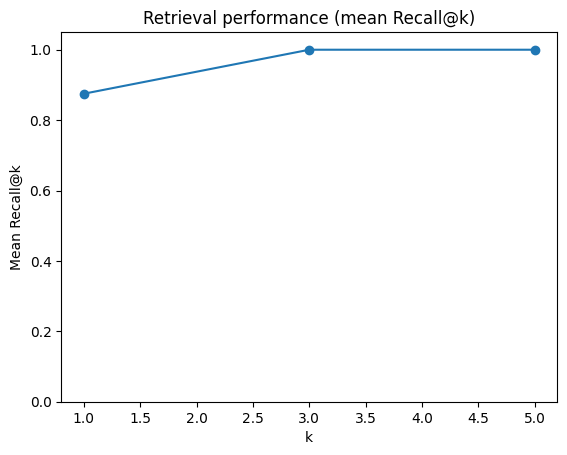

In [ ]:
ks = [1,3,5]
recalls = [retrieval_eval[f"Recall@{k}"].mean() for k in ks]

plt.figure()
plt.plot(ks, recalls, marker="o")
plt.xlabel("k")
plt.ylabel("Mean Recall@k")
plt.title("Retrieval performance (mean Recall@k)")
plt.ylim(0, 1.05)
plt.show()


## 20) Mini-ablation: chunk size sensitivity (optional but informative)

Chunk size is one of the most important knobs in RAG.

In this quick ablation we:
- rebuild chunks + embeddings + index for a few chunk sizes
- measure retrieval metrics again

On a large corpus, you would cache embeddings and do this more carefully.


In [ ]:
def build_index_for_chunk_params(max_tokens, overlap_tokens):
    temp_chunks = build_chunks(DOCUMENTS, max_tokens=max_tokens, overlap_tokens=overlap_tokens)
    temp_embs = embed_texts(temp_chunks["text"].tolist(), batch_size=32, normalize=True).astype(np.float32)
    temp_index = faiss.IndexFlatIP(temp_embs.shape[1])
    temp_index.add(temp_embs)

    def temp_retrieve(query: str, k: int = 5):
        q_emb = embed_texts([query], batch_size=1, normalize=True).astype(np.float32)
        scores, idxs = temp_index.search(q_emb, k)
        scores = scores[0].tolist()
        idxs = idxs[0].tolist()
        rows = []
        for rank, (score, i) in enumerate(zip(scores, idxs), start=1):
            if i == -1:
                continue
            row = temp_chunks.iloc[i].to_dict()
            row.update({"rank": rank, "score": float(score)})
            rows.append(row)
        return pd.DataFrame(rows)

    return temp_chunks, temp_retrieve

def evaluate_retrieval_with_custom_retriever(eval_set, retrieve_fn, k_values=(1,3,5)):
    rows = []
    for ex in eval_set:
        r = retrieve_fn(ex["question"], k=max(k_values))
        doc_ranking = []
        for d in r.sort_values("rank")["doc_id"].tolist():
            if d not in doc_ranking:
                doc_ranking.append(d)
        gold = set(ex["gold_docs"])
        row = {"MRR": mrr(doc_ranking, gold)}
        for k in k_values:
            row[f"Recall@{k}"] = recall_at_k(doc_ranking, gold, k)
        rows.append(row)
    return pd.DataFrame(rows).mean()

settings = [
    (64, 16),
    (128, 32),
    (256, 64),
]

ablation_rows = []
for max_t, ov in settings:
    temp_chunks, temp_retrieve = build_index_for_chunk_params(max_t, ov)
    metrics = evaluate_retrieval_with_custom_retriever(EVAL_SET, temp_retrieve, k_values=(1,3,5))
    ablation_rows.append({
        "chunk_max_tokens": max_t,
        "overlap_tokens": ov,
        "num_chunks": len(temp_chunks),
        "MRR": metrics["MRR"],
        "Recall@1": metrics["Recall@1"],
        "Recall@3": metrics["Recall@3"],
        "Recall@5": metrics["Recall@5"],
    })

ablation_df = pd.DataFrame(ablation_rows)
ablation_df


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

...

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

,chunk_max_tokens,overlap_tokens,num_chunks,MRR,Recall@1,Recall@3,Recall@5
0,64,16,13,0.9375,0.875,1.0,1.0
1,128,32,10,0.9375,0.875,1.0,1.0
2,256,64,10,0.9375,0.875,1.0,1.0
